In [ ]:
# ============================================================
# CELL 1 — IMPORTS & CONFIGURATION
# ============================================================

import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [ ]:
# Download Dataset

!pip -q install kagglehub
import kagglehub

# Download the latest version of the dataset
dataset_path = kagglehub.dataset_download(
    "ajg117/indian-paintings-dataset"
)

print("Dataset path:")
print(dataset_path)

Using Colab cache for faster access to the 'indian-paintings-dataset' dataset.
Dataset path:
/kaggle/input/indian-paintings-dataset


In [ ]:
# ============================================================
# CELL 3 — DATASET STRUCTURE & CLASS DISCOVERY
# ============================================================

print("Dataset path:")
print(dataset_path)

print("\nDataset contents:")
for item in sorted(os.listdir(dataset_path)):
    print(" -", item)

# ------------------------------------------------------------
# Dataset directory
# ------------------------------------------------------------

data_dir = dataset_path

# ------------------------------------------------------------
# Detect class folders
# ------------------------------------------------------------

class_folders = sorted([
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d))
])

print("\nDetected class folders:")
for i, class_name in enumerate(class_folders):
    print(f"{i}: {class_name}")

NUM_CLASSES = len(class_folders)

print("\nNumber of classes:", NUM_CLASSES)

# ------------------------------------------------------------
# Verify expected number of classes
# ------------------------------------------------------------

assert NUM_CLASSES == 8, (
    f"Expected 8 classes, but found {NUM_CLASSES}"
)

print("\n✓ Dataset contains exactly 8 classes.")

Dataset path:
/kaggle/input/indian-paintings-dataset

Dataset contents:
 - LICENSE
 - classes.csv
 - gond painting
 - kalighat painting
 - kangra painting
 - kerala mural
 - madhubani painting
 - mandana art drawing
 - pichwai painting
 - warli painting

Detected class folders:
0: gond painting
1: kalighat painting
2: kangra painting
3: kerala mural
4: madhubani painting
5: mandana art drawing
6: pichwai painting
7: warli painting

Number of classes: 8

✓ Dataset contains exactly 8 classes.


Dataset Distribution:


,Class,Image Count,Percentage
0,gond painting,98,10.304942
1,kalighat painting,244,25.657203
2,kangra painting,87,9.148265
3,kerala mural,94,9.884332
4,madhubani painting,95,9.989485
5,mandana art drawing,140,14.721346
6,pichwai painting,96,10.094637
7,warli painting,97,10.199790



Total images: 951


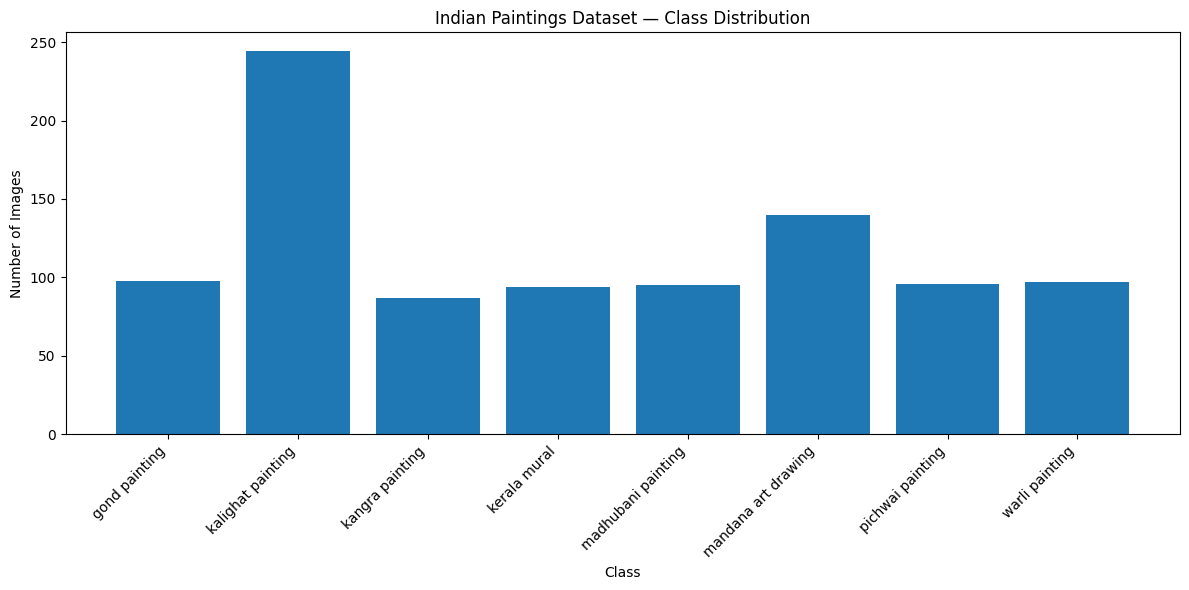

In [ ]:
# ============================================================
# CELL 4 — DATASET DISTRIBUTION
# ============================================================

image_extensions = (
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
)

class_counts = {}

for class_name in class_folders:
    class_path = os.path.join(data_dir, class_name)

    count = sum(
        1
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(image_extensions)
    )

    class_counts[class_name] = count

# ------------------------------------------------------------
# Create distribution table
# ------------------------------------------------------------

distribution_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Image Count"]
)

distribution_df["Percentage"] = (
    distribution_df["Image Count"]
    / distribution_df["Image Count"].sum()
    * 100
)

print("Dataset Distribution:")
display(distribution_df)

print("\nTotal images:", distribution_df["Image Count"].sum())

# ------------------------------------------------------------
# Plot distribution
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    distribution_df["Class"],
    distribution_df["Image Count"]
)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Indian Paintings Dataset — Class Distribution")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 5 — IMAGE TRANSFORMS & DATASET PREPARATION
# ============================================================

# ------------------------------------------------------------
# ImageNet normalization
# ------------------------------------------------------------

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# ------------------------------------------------------------
# Training transformations
# ------------------------------------------------------------

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# ------------------------------------------------------------
# Validation/Test transformations
# ------------------------------------------------------------

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# ------------------------------------------------------------
# Create base dataset
# ------------------------------------------------------------

base_dataset = datasets.ImageFolder(
    root=data_dir
)

print("Classes detected by ImageFolder:")
print(base_dataset.classes)

print("\nClass-to-index mapping:")
print(base_dataset.class_to_idx)

print("\nTotal images:", len(base_dataset))

Classes detected by ImageFolder:
['gond painting', 'kalighat painting', 'kangra painting', 'kerala mural', 'madhubani painting', 'mandana art drawing', 'pichwai painting', 'warli painting']

Class-to-index mapping:
{'gond painting': 0, 'kalighat painting': 1, 'kangra painting': 2, 'kerala mural': 3, 'madhubani painting': 4, 'mandana art drawing': 5, 'pichwai painting': 6, 'warli painting': 7}

Total images: 953


In [ ]:
# ============================================================
# CELL 6 — TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# ------------------------------------------------------------
# Get all image paths and labels
# ------------------------------------------------------------

all_samples = base_dataset.samples

all_paths = np.array([sample[0] for sample in all_samples])
all_labels = np.array([sample[1] for sample in all_samples])

# ------------------------------------------------------------
# First split:
# 80% Train + 20% Temporary
# ------------------------------------------------------------

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.20,
    random_state=SEED,
    stratify=all_labels
)

# ------------------------------------------------------------
# Second split:
# 10% Validation + 10% Test
# ------------------------------------------------------------

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("Dataset split:")
print("----------------------------")
print(f"Training images   : {len(train_paths)}")
print(f"Validation images : {len(val_paths)}")
print(f"Test images       : {len(test_paths)}")
print(f"Total images      : {len(all_paths)}")

# ------------------------------------------------------------
# Helper dataset class
# ------------------------------------------------------------

class PaintingDataset(torch.utils.data.Dataset):

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        image_path = self.image_paths[idx]
        label = int(self.labels[idx])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

train_dataset = PaintingDataset(
    train_paths,
    train_labels,
    transform=train_transform
)

val_dataset = PaintingDataset(
    val_paths,
    val_labels,
    transform=eval_transform
)

test_dataset = PaintingDataset(
    test_paths,
    test_labels,
    transform=eval_transform
)

print("\n✓ Train dataset created")
print("✓ Validation dataset created")
print("✓ Test dataset created")

Dataset split:
----------------------------
Training images   : 762
Validation images : 95
Test images       : 96
Total images      : 953

✓ Train dataset created
✓ Validation dataset created
✓ Test dataset created


In [ ]:
# ============================================================
# CELL 7 — CREATE DATALOADERS
# ============================================================

# ------------------------------------------------------------
# Batch size
# ------------------------------------------------------------

BATCH_SIZE = 32

# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

# ------------------------------------------------------------
# Verify one batch
# ------------------------------------------------------------

images, labels = next(iter(train_loader))

print("DataLoader verification:")
print("----------------------------")
print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)
print("Batch size        :", images.size(0))
print("Number of classes :", NUM_CLASSES)

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


DataLoader verification:
----------------------------
Image batch shape : torch.Size([32, 3, 224, 224])
Label batch shape : torch.Size([32])
Batch size        : 32
Number of classes : 8


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


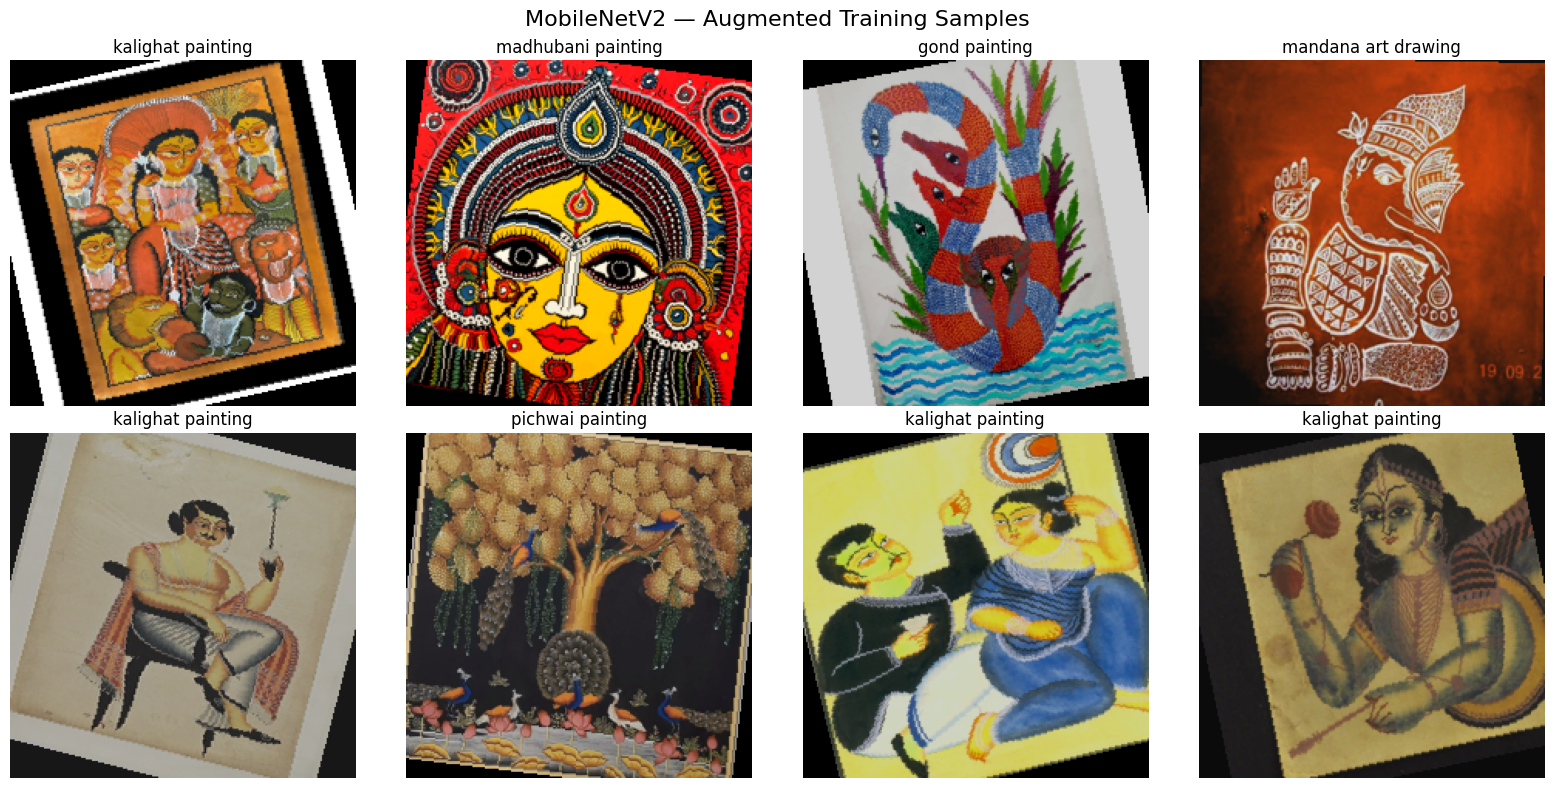

In [ ]:
# ============================================================
# CELL 8 — VISUALIZE TRAINING SAMPLES
# ============================================================

# ImageNet values used for normalization
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

# Get one batch
images, labels = next(iter(train_loader))

# Number of images to display
num_images = min(8, len(images))

plt.figure(figsize=(16, 8))

for i in range(num_images):

    # Undo normalization for visualization
    image = images[i].cpu() * std + mean

    # Convert from CHW -> HWC
    image = image.permute(1, 2, 0).numpy()

    # Keep pixel values valid
    image = np.clip(image, 0, 1)

    plt.subplot(2, 4, i + 1)

    plt.imshow(image)

    plt.title(
        base_dataset.classes[labels[i].item()]
    )

    plt.axis("off")

plt.suptitle(
    "MobileNetV2 — Augmented Training Samples",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 9 — MOBILE NET V2 MODEL
# ============================================================

# ------------------------------------------------------------
# Load ImageNet-pretrained MobileNetV2
# ------------------------------------------------------------

weights = models.MobileNet_V2_Weights.DEFAULT

model = models.mobilenet_v2(
    weights=weights
)

# ------------------------------------------------------------
# Freeze the pretrained backbone
# ------------------------------------------------------------

for param in model.features.parameters():
    param.requires_grad = False

# ------------------------------------------------------------
# Replace the original ImageNet classifier
# ------------------------------------------------------------

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(num_features, NUM_CLASSES)
)

# ------------------------------------------------------------
# Move model to device
# ------------------------------------------------------------

model = model.to(device)

# ------------------------------------------------------------
# Model information
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("MobileNetV2 Model")
print("============================")
print("Architecture       : MobileNetV2")
print("Pretrained weights  : ImageNet")
print("Number of classes   :", NUM_CLASSES)
print("Input size          : 224 x 224")
print("Total parameters    :", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")
print("Device              :", device)

print("\nClassifier:")
print(model.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 88.7MB/s]


MobileNetV2 Model
Architecture       : MobileNetV2
Pretrained weights  : ImageNet
Number of classes   : 8
Input size          : 224 x 224
Total parameters    : 2,234,120
Trainable parameters: 10,248
Device              : cuda

Classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=8, bias=True)
)


In [ ]:
# ============================================================
# CELL 10 — LOSS FUNCTION & OPTIMIZER
# ============================================================

# ------------------------------------------------------------
# Loss function
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

# ------------------------------------------------------------
# Learning-rate scheduler
# ------------------------------------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("Loss function : CrossEntropyLoss")
print("Optimizer     : AdamW")
print("Learning rate :", 1e-3)
print("Weight decay  :", 1e-4)
print("Scheduler     : ReduceLROnPlateau")

Loss function : CrossEntropyLoss
Optimizer     : AdamW
Learning rate : 0.001
Weight decay  : 0.0001
Scheduler     : ReduceLROnPlateau


In [ ]:
# ============================================================
# CELL 11 — TRAINING & VALIDATION FUNCTIONS
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    Returns:
        average_loss
        accuracy
        epoch_time
    """

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    start_time = time.perf_counter()

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear gradients
        optimizer.zero_grad(set_to_none=True)

        # Forward pass
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    epoch_time = time.perf_counter() - start_time

    average_loss = running_loss / total
    accuracy = correct / total

    return average_loss, accuracy, epoch_time


# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate_model(model, loader, criterion, device):
    """
    Evaluate the model on validation data.
    Returns:
        average_loss
        accuracy
        validation_time
    """

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    start_time = time.perf_counter()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Forward pass
            outputs = model(images)

            # Loss
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)

            _, predictions = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    validation_time = time.perf_counter() - start_time

    average_loss = running_loss / total
    accuracy = correct / total

    return average_loss, accuracy, validation_time


print("✓ Training function created")
print("✓ Validation function created")
print("✓ Epoch timing enabled")

✓ Training function created
✓ Validation function created
✓ Epoch timing enabled


In [ ]:
# ============================================================
# CELL 12 — STAGE 1: FROZEN BACKBONE TRAINING
# ============================================================

NUM_EPOCHS_STAGE1 = 5

best_val_accuracy_stage1 = 0.0
best_model_stage1 = None

stage1_history = {
    "train_loss": [],
    "train_accuracy": [],
    "train_time": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_time": []
}

stage1_start_time = time.perf_counter()

print("=" * 70)
print("STAGE 1 — FROZEN MOBILENETV2 BACKBONE")
print("=" * 70)

for epoch in range(NUM_EPOCHS_STAGE1):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    train_loss, train_accuracy, train_time = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_loss, val_accuracy, val_time = validate_model(
        model,
        val_loader,
        criterion,
        device
    )

    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step(val_accuracy)

    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    stage1_history["train_loss"].append(train_loss)
    stage1_history["train_accuracy"].append(train_accuracy)

    stage1_history["train_time"].append(train_time)

    stage1_history["val_loss"].append(val_loss)
    stage1_history["val_accuracy"].append(val_accuracy)

    stage1_history["val_time"].append(val_time)

    # --------------------------------------------------------
    # Save best model in memory
    # --------------------------------------------------------

    if val_accuracy > best_val_accuracy_stage1:

        best_val_accuracy_stage1 = val_accuracy

        best_model_stage1 = copy.deepcopy(
            model.state_dict()
        )

    # --------------------------------------------------------
    # Print epoch results
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS_STAGE1}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Train Time: {train_time:.2f}s | "
        f"Val Time: {val_time:.2f}s"
    )

stage1_total_time = time.perf_counter() - stage1_start_time

# ------------------------------------------------------------
# Restore best Stage 1 model
# ------------------------------------------------------------

model.load_state_dict(best_model_stage1)

print("\n" + "=" * 70)
print("STAGE 1 COMPLETE")
print("=" * 70)

print(
    f"Best Stage 1 validation accuracy: "
    f"{best_val_accuracy_stage1:.4f}"
)

print(
    f"Stage 1 total training time: "
    f"{stage1_total_time:.2f} seconds"
)

STAGE 1 — FROZEN MOBILENETV2 BACKBONE


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/5] | Train Loss: 1.8036 | Train Acc: 0.3084 | Val Loss: 1.5257 | Val Acc: 0.4632 | Train Time: 21.49s | Val Time: 3.69s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [2/5] | Train Loss: 1.3438 | Train Acc: 0.6102 | Val Loss: 1.2016 | Val Acc: 0.6632 | Train Time: 18.87s | Val Time: 2.16s


...

Epoch [3/5] | Train Loss: 1.0910 | Train Acc: 0.7034 | Val Loss: 1.0190 | Val Acc: 0.6947 | Train Time: 20.23s | Val Time: 2.16s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [4/5] | Train Loss: 0.9069 | Train Acc: 0.7913 | Val Loss: 0.9013 | Val Acc: 0.7158 | Train Time: 19.10s | Val Time: 2.92s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [5/5] | Train Loss: 0.8167 | Train Acc: 0.7782 | Val Loss: 0.8238 | Val Acc: 0.7895 | Train Time: 18.68s | Val Time: 2.12s

STAGE 1 COMPLETE
Best Stage 1 validation accuracy: 0.7895
Stage 1 total training time: 111.57 seconds


In [ ]:
# ============================================================
# CELL 13 — STAGE 2: UNFREEZE & FINE-TUNE MOBILENETV2
# ============================================================

# ------------------------------------------------------------
# Unfreeze MobileNetV2 feature extractor
# ------------------------------------------------------------

for param in model.features.parameters():
    param.requires_grad = True

# ------------------------------------------------------------
# Create a new optimizer with a smaller learning rate
# ------------------------------------------------------------

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# ------------------------------------------------------------
# Learning-rate scheduler
# ------------------------------------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 70)
print("STAGE 2 — MOBILENETV2 FINE-TUNING")
print("=" * 70)

print("Backbone status    : UNFROZEN")
print("Learning rate      : 0.0001")
print("Weight decay       : 0.0001")
print("Total parameters   :", f"{total_params:,}")
print("Trainable params   :", f"{trainable_params:,}")
print("Optimizer          : AdamW")
print("Scheduler           : ReduceLROnPlateau")

STAGE 2 — MOBILENETV2 FINE-TUNING
Backbone status    : UNFROZEN
Learning rate      : 0.0001
Weight decay       : 0.0001
Total parameters   : 2,234,120
Trainable params   : 2,234,120
Optimizer          : AdamW
Scheduler           : ReduceLROnPlateau


In [ ]:
# ============================================================
# CELL 14 — STAGE 2: FINE-TUNING TRAINING LOOP
# ============================================================

NUM_EPOCHS_STAGE2 = 10

best_val_accuracy_stage2 = 0.0
best_model_stage2 = None

stage2_history = {
    "train_loss": [],
    "train_accuracy": [],
    "train_time": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_time": []
}

stage2_start_time = time.perf_counter()

print("=" * 70)
print("STAGE 2 — MOBILENETV2 FINE-TUNING")
print("=" * 70)

for epoch in range(NUM_EPOCHS_STAGE2):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    train_loss, train_accuracy, train_time = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_loss, val_accuracy, val_time = validate_model(
        model,
        val_loader,
        criterion,
        device
    )

    # --------------------------------------------------------
    # Learning-rate scheduler
    # --------------------------------------------------------

    scheduler.step(val_accuracy)

    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    stage2_history["train_loss"].append(train_loss)
    stage2_history["train_accuracy"].append(train_accuracy)
    stage2_history["train_time"].append(train_time)

    stage2_history["val_loss"].append(val_loss)
    stage2_history["val_accuracy"].append(val_accuracy)
    stage2_history["val_time"].append(val_time)

    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if val_accuracy > best_val_accuracy_stage2:

        best_val_accuracy_stage2 = val_accuracy

        best_model_stage2 = copy.deepcopy(
            model.state_dict()
        )

    # --------------------------------------------------------
    # Current learning rate
    # --------------------------------------------------------

    current_lr = optimizer.param_groups[0]["lr"]

    # --------------------------------------------------------
    # Print epoch results
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS_STAGE2}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"Train Time: {train_time:.2f}s | "
        f"Val Time: {val_time:.2f}s"
    )

stage2_total_time = time.perf_counter() - stage2_start_time

# ------------------------------------------------------------
# Restore best Stage 2 model
# ------------------------------------------------------------

model.load_state_dict(best_model_stage2)

print("\n" + "=" * 70)
print("STAGE 2 COMPLETE")
print("=" * 70)

print(
    f"Best Stage 2 validation accuracy: "
    f"{best_val_accuracy_stage2:.4f}"
)

print(
    f"Stage 2 training time: "
    f"{stage2_total_time:.2f} seconds"
)

# ------------------------------------------------------------
# Total training time so far
# ------------------------------------------------------------

mobileNet_training_time = (
    stage1_total_time +
    stage2_total_time
)

print(
    f"Total MobileNetV2 training time: "
    f"{mobileNet_training_time:.2f} seconds"
)

STAGE 2 — MOBILENETV2 FINE-TUNING


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/10] | Train Loss: 0.6328 | Train Acc: 0.8255 | Val Loss: 0.5758 | Val Acc: 0.8316 | LR: 1.00e-04 | Train Time: 21.14s | Val Time: 2.13s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [2/10] | Train Loss: 0.4396 | Train Acc: 0.8871 | Val Loss: 0.4661 | Val Acc: 0.8842 | LR: 1.00e-04 | Train Time: 21.03s | Val Time: 3.33s


...

Epoch [8/10] | Train Loss: 0.1106 | Train Acc: 0.9803 | Val Loss: 0.2591 | Val Acc: 0.9263 | LR: 1.00e-04 | Train Time: 21.12s | Val Time: 2.12s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [9/10] | Train Loss: 0.0946 | Train Acc: 0.9790 | Val Loss: 0.2599 | Val Acc: 0.9368 | LR: 5.00e-05 | Train Time: 19.97s | Val Time: 2.98s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [10/10] | Train Loss: 0.0728 | Train Acc: 0.9882 | Val Loss: 0.2437 | Val Acc: 0.9263 | LR: 5.00e-05 | Train Time: 19.37s | Val Time: 2.13s

STAGE 2 COMPLETE
Best Stage 2 validation accuracy: 0.9579
Stage 2 training time: 226.35 seconds
Total MobileNetV2 training time: 337.92 seconds


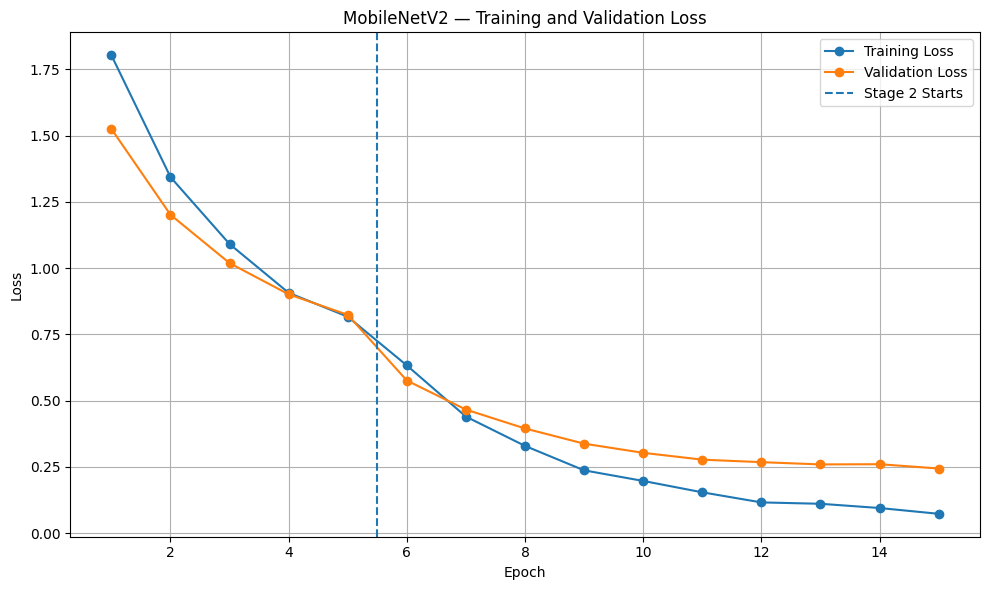

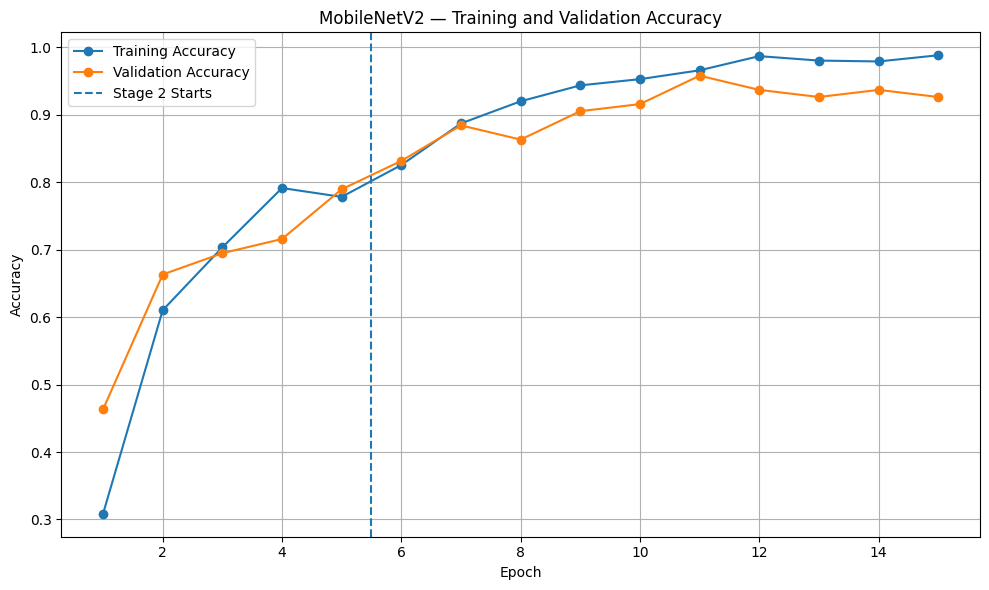

LEARNING CURVE SUMMARY
Best validation accuracy : 0.9579
Best epoch               : 11


In [ ]:
# ============================================================
# CELL 15 — COMBINE HISTORY & PLOT LEARNING CURVES
# ============================================================

# ------------------------------------------------------------
# Combine Stage 1 and Stage 2 histories
# ------------------------------------------------------------

combined_history = {
    "train_loss": (
        stage1_history["train_loss"] +
        stage2_history["train_loss"]
    ),

    "train_accuracy": (
        stage1_history["train_accuracy"] +
        stage2_history["train_accuracy"]
    ),

    "val_loss": (
        stage1_history["val_loss"] +
        stage2_history["val_loss"]
    ),

    "val_accuracy": (
        stage1_history["val_accuracy"] +
        stage2_history["val_accuracy"]
    ),

    "train_time": (
        stage1_history["train_time"] +
        stage2_history["train_time"]
    ),

    "val_time": (
        stage1_history["val_time"] +
        stage2_history["val_time"]
    )
}

epochs = range(
    1,
    len(combined_history["train_loss"]) + 1
)

# ------------------------------------------------------------
# Plot Loss
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    combined_history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    combined_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

# Mark Stage 1 / Stage 2 transition
plt.axvline(
    x=NUM_EPOCHS_STAGE1 + 0.5,
    linestyle="--",
    label="Stage 2 Starts"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 — Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot Accuracy
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    combined_history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    combined_history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    x=NUM_EPOCHS_STAGE1 + 0.5,
    linestyle="--",
    label="Stage 2 Starts"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 — Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print best validation accuracy
# ------------------------------------------------------------

best_overall_val_accuracy = max(
    combined_history["val_accuracy"]
)

best_epoch = (
    np.argmax(
        combined_history["val_accuracy"]
    ) + 1
)

print("=" * 70)
print("LEARNING CURVE SUMMARY")
print("=" * 70)

print(
    f"Best validation accuracy : "
    f"{best_overall_val_accuracy:.4f}"
)

print(
    f"Best epoch               : "
    f"{best_epoch}"
)

In [ ]:
# ============================================================
# CELL 16 — FINAL TEST EVALUATION
# ============================================================

# ------------------------------------------------------------
# Ensure best model is loaded
# ------------------------------------------------------------

model.load_state_dict(best_model_stage2)
model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

test_predictions = []
test_true_labels = []

# ------------------------------------------------------------
# Measure test evaluation time
# ------------------------------------------------------------

test_start_time = time.perf_counter()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (
            predictions == labels
        ).sum().item()

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_true_labels.extend(
            labels.cpu().numpy()
        )

test_evaluation_time = (
    time.perf_counter() - test_start_time
)

# ------------------------------------------------------------
# Convert to NumPy
# ------------------------------------------------------------

test_predictions = np.array(test_predictions)
test_true_labels = np.array(test_true_labels)

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

test_loss = test_loss / test_total

test_accuracy = accuracy_score(
    test_true_labels,
    test_predictions
)

test_precision = precision_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Print overall results
# ------------------------------------------------------------

print("=" * 70)
print("MOBILENETV2 — FINAL TEST RESULTS")
print("=" * 70)

print(f"Test Loss       : {test_loss:.4f}")
print(f"Test Accuracy   : {test_accuracy:.4f}")
print(f"Test Precision  : {test_precision:.4f}")
print(f"Test Recall     : {test_recall:.4f}")
print(f"Test F1-Score   : {test_f1:.4f}")

print(
    f"\nTest evaluation time: "
    f"{test_evaluation_time:.2f} seconds"
)

print(
    f"Test samples: "
    f"{test_total}"
)

MOBILENETV2 — FINAL TEST RESULTS
Test Loss       : 0.2640
Test Accuracy   : 0.9375
Test Precision  : 0.9414
Test Recall     : 0.9375
Test F1-Score   : 0.9380

Test evaluation time: 4.46 seconds
Test samples: 96


In [ ]:
# ============================================================
# CELL 17 — 8-CLASS CLASSIFICATION REPORT
# ============================================================

# ------------------------------------------------------------
# Generate classification report
# ------------------------------------------------------------

classification_report_dict = classification_report(
    test_true_labels,
    test_predictions,
    target_names=base_dataset.classes,
    output_dict=True,
    zero_division=0
)

# ------------------------------------------------------------
# Convert report to DataFrame
# ------------------------------------------------------------

classification_report_df = pd.DataFrame(
    classification_report_dict
).transpose()

# ------------------------------------------------------------
# Keep useful columns
# ------------------------------------------------------------

classification_report_df = classification_report_df[
    [
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
]

# ------------------------------------------------------------
# Display class-wise results
# ------------------------------------------------------------

print("=" * 70)
print("MOBILENETV2 — CLASS-WISE CLASSIFICATION REPORT")
print("=" * 70)

display(
    classification_report_df.round(4)
)

MOBILENETV2 — CLASS-WISE CLASSIFICATION REPORT


,precision,recall,f1-score,support
gond painting,1.0000,0.9000,0.9474,10.0000
kalighat painting,1.0000,0.9600,0.9796,25.0000
kangra painting,1.0000,0.8750,0.9333,8.0000
kerala mural,1.0000,1.0000,1.0000,10.0000
madhubani painting,0.9000,1.0000,0.9474,9.0000
mandana art drawing,0.8571,0.8571,0.8571,14.0000
pichwai painting,0.9091,1.0000,0.9524,10.0000
warli painting,0.8182,0.9000,0.8571,10.0000
accuracy,0.9375,0.9375,0.9375,0.9375
macro avg,0.9356,0.9365,0.9343,96.0000


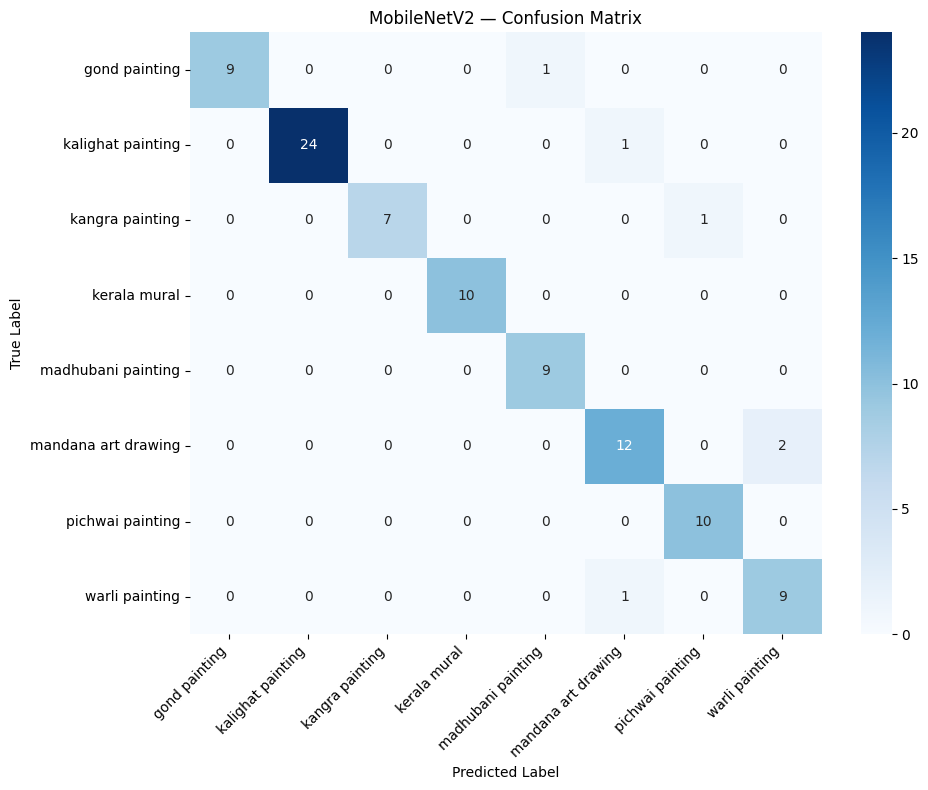

Confusion Matrix:
[[ 9  0  0  0  1  0  0  0]
 [ 0 24  0  0  0  1  0  0]
 [ 0  0  7  0  0  0  1  0]
 [ 0  0  0 10  0  0  0  0]
 [ 0  0  0  0  9  0  0  0]
 [ 0  0  0  0  0 12  0  2]
 [ 0  0  0  0  0  0 10  0]
 [ 0  0  0  0  0  1  0  9]]


In [ ]:
# ============================================================
# CELL 18 — CONFUSION MATRIX
# ============================================================

# ------------------------------------------------------------
# Generate confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    test_true_labels,
    test_predictions
)

# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=base_dataset.classes,
    yticklabels=base_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "MobileNetV2 — Confusion Matrix"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print matrix
# ------------------------------------------------------------

print("Confusion Matrix:")
print(cm)

In [ ]:
# ============================================================
# CELL 19 — INFERENCE TIME BENCHMARK
# ============================================================

model.load_state_dict(best_model_stage2)
model.eval()

# ------------------------------------------------------------
# Warm-up
# ------------------------------------------------------------

WARMUP_BATCHES = 3

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        images = images.to(device, non_blocking=True)

        _ = model(images)

        if batch_idx + 1 >= WARMUP_BATCHES:
            break

# Synchronize GPU before starting benchmark
if torch.cuda.is_available():
    torch.cuda.synchronize()

# ------------------------------------------------------------
# Timed inference
# ------------------------------------------------------------

inference_start_time = time.perf_counter()

total_inference_images = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)

        _ = model(images)

        total_inference_images += images.size(0)

# Synchronize GPU after inference
if torch.cuda.is_available():
    torch.cuda.synchronize()

inference_total_time = (
    time.perf_counter() - inference_start_time
)

# ------------------------------------------------------------
# Calculate benchmark metrics
# ------------------------------------------------------------

average_inference_time = (
    inference_total_time /
    total_inference_images
)

inference_throughput = (
    total_inference_images /
    inference_total_time
)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("=" * 70)
print("MOBILENETV2 — INFERENCE BENCHMARK")
print("=" * 70)

print(
    f"Images evaluated          : "
    f"{total_inference_images}"
)

print(
    f"Total inference time      : "
    f"{inference_total_time:.4f} seconds"
)

print(
    f"Average time per image    : "
    f"{average_inference_time * 1000:.4f} ms"
)

print(
    f"Inference throughput      : "
    f"{inference_throughput:.2f} images/second"
)

MOBILENETV2 — INFERENCE BENCHMARK
Images evaluated          : 96
Total inference time      : 2.8966 seconds
Average time per image    : 30.1726 ms
Inference throughput      : 33.14 images/second


In [ ]:
# ============================================================
# CELL 20 — MODEL COMPLEXITY & SIZE BENCHMARK
# ============================================================

# ------------------------------------------------------------
# Parameter counts
# ------------------------------------------------------------

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

non_trainable_parameters = (
    total_parameters -
    trainable_parameters
)

# ------------------------------------------------------------
# Model state dictionary size
# ------------------------------------------------------------

model_size_bytes = sum(
    tensor.numel() * tensor.element_size()
    for tensor in model.state_dict().values()
)

model_size_mb = (
    model_size_bytes /
    (1024 ** 2)
)

model_size_gb = (
    model_size_bytes /
    (1024 ** 3)
)

# ------------------------------------------------------------
# Calculate training statistics
# ------------------------------------------------------------

average_epoch_training_time = (
    np.mean(
        combined_history["train_time"]
    )
)

average_epoch_validation_time = (
    np.mean(
        combined_history["val_time"]
    )
)

# ------------------------------------------------------------
# Print benchmark
# ------------------------------------------------------------

print("=" * 70)
print("MOBILENETV2 — MODEL COMPLEXITY BENCHMARK")
print("=" * 70)

print(
    f"Total parameters           : "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters       : "
    f"{trainable_parameters:,}"
)

print(
    f"Non-trainable parameters   : "
    f"{non_trainable_parameters:,}"
)

print(
    f"Model size                 : "
    f"{model_size_mb:.2f} MB"
)

print(
    f"Total training time        : "
    f"{mobileNet_training_time:.2f} seconds"
)

print(
    f"Average epoch train time   : "
    f"{average_epoch_training_time:.2f} seconds"
)

print(
    f"Average epoch validation   : "
    f"{average_epoch_validation_time:.2f} seconds"
)

print(
    f"Average inference time     : "
    f"{average_inference_time * 1000:.4f} ms/image"
)

print(
    f"Inference throughput      : "
    f"{inference_throughput:.2f} images/sec"
)

MOBILENETV2 — MODEL COMPLEXITY BENCHMARK
Total parameters           : 2,234,120
Trainable parameters       : 2,234,120
Non-trainable parameters   : 0
Model size                 : 8.65 MB
Total training time        : 337.92 seconds
Average epoch train time   : 20.02 seconds
Average epoch validation   : 2.49 seconds
Average inference time     : 30.1726 ms/image
Inference throughput      : 33.14 images/sec


In [ ]:
# ============================================================
# CELL 21 — FINAL MOBILENETV2 BENCHMARK RECORD
# ============================================================

mobilenetv2_results = {
    "Model": "MobileNetV2",

    # --------------------------------------------------------
    # Performance metrics
    # --------------------------------------------------------

    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1-Score": test_f1,

    # --------------------------------------------------------
    # Validation performance
    # --------------------------------------------------------

    "Best Validation Accuracy": best_overall_val_accuracy,

    # --------------------------------------------------------
    # Training benchmark
    # --------------------------------------------------------

    "Training Time (sec)": mobileNet_training_time,
    "Stage 1 Training Time (sec)": stage1_total_time,
    "Stage 2 Training Time (sec)": stage2_total_time,

    # --------------------------------------------------------
    # Inference benchmark
    # --------------------------------------------------------

    "Inference Time (sec)": inference_total_time,
    "Inference Time (ms/image)": (
        average_inference_time * 1000
    ),
    "Inference Throughput (images/sec)": (
        inference_throughput
    ),

    # --------------------------------------------------------
    # Model complexity
    # --------------------------------------------------------

    "Total Parameters": total_parameters,
    "Trainable Parameters": trainable_parameters,
    "Non-Trainable Parameters": non_trainable_parameters,
    "Model Size (MB)": model_size_mb
}

# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

mobilenetv2_benchmark_df = pd.DataFrame(
    [mobilenetv2_results]
)

print("=" * 70)
print("MOBILENETV2 — FINAL BENCHMARK")
print("=" * 70)

display(
    mobilenetv2_benchmark_df.round(4)
)

MOBILENETV2 — FINAL BENCHMARK


,Model,Accuracy,Precision,Recall,F1-Score,Best Validation Accuracy,Training Time (sec),Stage 1 Training Time (sec),Stage 2 Training Time (sec),Inference Time (sec),Inference Time (ms/image),Inference Throughput (images/sec),Total Parameters,Trainable Parameters,Non-Trainable Parameters,Model Size (MB)
0,MobileNetV2,0.9375,0.9414,0.9375,0.938,0.9579,337.9177,111.5652,226.3525,2.8966,30.1726,33.1427,2234120,2234120,0,8.653


In [ ]:
# ============================================================
# CELL 22 — SAVE BEST MOBILENETV2 MODEL
# ============================================================

# ------------------------------------------------------------
# Create output directory
# ------------------------------------------------------------

output_dir = "/kaggle/working/mobilenetv2_results"

os.makedirs(
    output_dir,
    exist_ok=True
)

# ------------------------------------------------------------
# Model checkpoint
# ------------------------------------------------------------

checkpoint_path = os.path.join(
    output_dir,
    "mobilenetv2_best.pth"
)

checkpoint = {
    "model_name": "MobileNetV2",

    "model_state_dict": model.state_dict(),

    "num_classes": NUM_CLASSES,

    "class_names": base_dataset.classes,

    "class_to_idx": base_dataset.class_to_idx,

    "best_validation_accuracy": best_overall_val_accuracy,

    "test_accuracy": test_accuracy,

    "test_precision": test_precision,

    "test_recall": test_recall,

    "test_f1": test_f1,

    "training_time_seconds": mobileNet_training_time,

    "inference_time_seconds": inference_total_time,

    "inference_time_ms_per_image": (
        average_inference_time * 1000
    ),

    "inference_throughput": inference_throughput,

    "total_parameters": total_parameters,

    "trainable_parameters": trainable_parameters,

    "model_size_mb": model_size_mb
}

torch.save(
    checkpoint,
    checkpoint_path
)

print("=" * 70)
print("MODEL SAVED")
print("=" * 70)

print("Checkpoint path:")
print(checkpoint_path)

print(
    f"\nFile size: "
    f"{os.path.getsize(checkpoint_path) / (1024 ** 2):.2f} MB"
)

MODEL SAVED
Checkpoint path:
/kaggle/working/mobilenetv2_results/mobilenetv2_best.pth

File size: 8.76 MB


In [ ]:
# ============================================================
# CELL 23 — SAVE CLASS-WISE METRICS
# ============================================================

# ------------------------------------------------------------
# Create a clean class-wise table
# ------------------------------------------------------------

classwise_metrics_df = classification_report_df.copy()

classwise_metrics_df.index.name = "Class"

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

classwise_metrics_path = os.path.join(
    output_dir,
    "mobilenetv2_classwise_metrics.csv"
)

classwise_metrics_df.to_csv(
    classwise_metrics_path
)

# ------------------------------------------------------------
# Save overall benchmark
# ------------------------------------------------------------

benchmark_path = os.path.join(
    output_dir,
    "mobilenetv2_benchmark.csv"
)

mobilenetv2_benchmark_df.to_csv(
    benchmark_path,
    index=False
)

print("=" * 70)
print("METRICS SAVED")
print("=" * 70)

print("\nClass-wise metrics:")
print(classwise_metrics_path)

print("\nOverall benchmark:")
print(benchmark_path)

print("\n✓ MobileNetV2 metrics successfully saved.")

METRICS SAVED

Class-wise metrics:
/kaggle/working/mobilenetv2_results/mobilenetv2_classwise_metrics.csv

Overall benchmark:
/kaggle/working/mobilenetv2_results/mobilenetv2_benchmark.csv

✓ MobileNetV2 metrics successfully saved.


In [ ]:
# ============================================================
# CELL 24 — FINAL MOBILENETV2 SUMMARY
# ============================================================

print("=" * 75)
print("MOBILENETV2 — FINAL EXPERIMENT SUMMARY")
print("=" * 75)

print("\nMODEL")
print("-" * 75)
print("Architecture              : MobileNetV2")
print("Pretrained weights        : ImageNet")
print("Number of classes         :", NUM_CLASSES)
print("Input resolution          : 224 x 224")

print("\nPERFORMANCE")
print("-" * 75)
print(f"Best Validation Accuracy : {best_overall_val_accuracy:.4f}")
print(f"Test Accuracy             : {test_accuracy:.4f}")
print(f"Test Precision            : {test_precision:.4f}")
print(f"Test Recall               : {test_recall:.4f}")
print(f"Test F1-Score             : {test_f1:.4f}")

print("\nTRAINING BENCHMARK")
print("-" * 75)
print(f"Stage 1 Training Time    : {stage1_total_time:.2f} sec")
print(f"Stage 2 Training Time    : {stage2_total_time:.2f} sec")
print(f"Total Training Time      : {mobileNet_training_time:.2f} sec")

print("\nINFERENCE BENCHMARK")
print("-" * 75)
print(f"Total Inference Time     : {inference_total_time:.4f} sec")
print(
    f"Average Inference Time   : "
    f"{average_inference_time * 1000:.4f} ms/image"
)
print(
    f"Inference Throughput     : "
    f"{inference_throughput:.2f} images/sec"
)

print("\nMODEL COMPLEXITY")
print("-" * 75)
print(f"Total Parameters         : {total_parameters:,}")
print(f"Trainable Parameters     : {trainable_parameters:,}")
print(f"Non-Trainable Parameters : {non_trainable_parameters:,}")
print(f"Model Size               : {model_size_mb:.2f} MB")

print("\nOUTPUT DIRECTORY")
print("-" * 75)
print(output_dir)

print("\n✓ MobileNetV2 experiment completed.")

MOBILENETV2 — FINAL EXPERIMENT SUMMARY

MODEL
---------------------------------------------------------------------------
Architecture              : MobileNetV2
Pretrained weights        : ImageNet
Number of classes         : 8
Input resolution          : 224 x 224

PERFORMANCE
---------------------------------------------------------------------------
Best Validation Accuracy : 0.9579
Test Accuracy             : 0.9375
Test Precision            : 0.9414
Test Recall               : 0.9375
Test F1-Score             : 0.9380

TRAINING BENCHMARK
---------------------------------------------------------------------------
Stage 1 Training Time    : 111.57 sec
Stage 2 Training Time    : 226.35 sec
Total Training Time      : 337.92 sec

INFERENCE BENCHMARK
---------------------------------------------------------------------------
Total Inference Time     : 2.8966 sec
Average Inference Time   : 30.1726 ms/image
Inference Throughput     : 33.14 images/sec

MODEL COMPLEXITY
-------------------

In [ ]:
# ============================================================
# CELL 25 — SAVE MOBILENETV2 RESULTS TO GOOGLE DRIVE
# ============================================================

from google.colab import drive
import shutil
import os

# ------------------------------------------------------------
# Mount Google Drive
# ------------------------------------------------------------

drive.mount("/content/drive")

# ------------------------------------------------------------
# Define Google Drive output directory
# ------------------------------------------------------------

drive_output_dir = (
    "/content/drive/MyDrive/"
    "Iconography/Implementation/MobileNet-V2"
)

os.makedirs(
    drive_output_dir,
    exist_ok=True
)

# ------------------------------------------------------------
# Copy all MobileNetV2 result files
# ------------------------------------------------------------

saved_files = []

for file_name in os.listdir(output_dir):

    source_path = os.path.join(
        output_dir,
        file_name
    )

    destination_path = os.path.join(
        drive_output_dir,
        file_name
    )

    if os.path.isfile(source_path):

        shutil.copy2(
            source_path,
            destination_path
        )

        saved_files.append(file_name)

# ------------------------------------------------------------
# Verify saved files
# ------------------------------------------------------------

print("=" * 75)
print("MOBILENETV2 — GOOGLE DRIVE SAVE")
print("=" * 75)

print("\nDrive location:")
print(drive_output_dir)

print("\nSaved files:")

for file_name in sorted(saved_files):

    file_path = os.path.join(
        drive_output_dir,
        file_name
    )

    file_size = (
        os.path.getsize(file_path)
        / (1024 ** 2)
    )

    print(
        f"✓ {file_name} "
        f"({file_size:.2f} MB)"
    )

print("\nTotal files saved:", len(saved_files))

# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

expected_files = [
    "mobilenetv2_best.pth",
    "mobilenetv2_classwise_metrics.csv",
    "mobilenetv2_benchmark.csv"
]

missing_files = [
    file_name
    for file_name in expected_files
    if not os.path.exists(
        os.path.join(
            drive_output_dir,
            file_name
        )
    )
]

if len(missing_files) == 0:

    print("\n" + "=" * 75)
    print("✓ ALL MOBILENETV2 FILES VERIFIED IN GOOGLE DRIVE")
    print("=" * 75)

else:

    print("\n⚠ Missing files:")

    for file_name in missing_files:
        print(" -", file_name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MOBILENETV2 — GOOGLE DRIVE SAVE

Drive location:
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V2

Saved files:
✓ mobilenetv2_benchmark.csv (0.00 MB)
✓ mobilenetv2_best.pth (8.76 MB)
✓ mobilenetv2_classwise_metrics.csv (0.00 MB)

Total files saved: 3

✓ ALL MOBILENETV2 FILES VERIFIED IN GOOGLE DRIVE
